# Data Preprocessing 
Load raw data, visualize, map labels, chunk windows, and normalize.

In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [14]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    get_feature_columns,
    create_windows,
    clean_features,
    normalize_features,
)
from data.motion_dataset import MotionDataset

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_type = "Segment Velocity"
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2


# Read data 

In [15]:
print("[phase=data] loading P1 + P2 datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 train/val
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing.csv"),
]
p1_df = pd.concat(p1_dfs, ignore_index=True)

# P2 test
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing.csv"),
]
p2_df = pd.concat(p2_dfs, ignore_index=True)

# Filter sensor
p1_df = p1_df[p1_df["sensor_type"] == sensor_type]
p2_df = p2_df[p2_df["sensor_type"] == sensor_type]

# Optional video suffix filter
if video_suffix is not None:
    p1_df = p1_df[p1_df["video_id"].str.endswith(video_suffix)]
    p2_df = p2_df[p2_df["video_id"].str.endswith(video_suffix)]

assert p1_df["activity_type"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["activity_type"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
p1_df.head()


[phase=data] loading P1 + P2 datasets
[phase=data] p1_rows=266924 p2_rows=263369


,Frame,Pelvis x,Pelvis y,Pelvis z,L5 x,L5 y,L5 z,L3 x,L3 y,L3 z,...,Left Foot z,Left Toe x,Left Toe y,Left Toe z,Label,person_id,activity_type,knife_sharpness_score,sensor_type,video_id
0,0,0,0,0,0.016263,-0.095142,0.221275,0.016263,-0.095142,0.221275,...,-0.008848,-0.051999,-0.007358,-0.008848,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
1,1,0,0,0,0.001253,-0.126477,0.188341,-0.007620,-0.133955,0.187839,...,-0.039315,-0.063777,-0.030254,-0.039315,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
2,2,0,0,0,-0.013758,-0.157811,0.155406,-0.031503,-0.172767,0.154402,...,-0.069782,-0.075555,-0.053150,-0.069782,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
3,3,0,0,0,-0.022041,-0.178102,0.134543,-0.045098,-0.198298,0.133187,...,-0.088753,-0.082192,-0.067862,-0.088753,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
4,4,0,0,0,-0.020406,-0.179536,0.134429,-0.042620,-0.201432,0.132967,...,-0.088076,-0.080588,-0.068582,-0.088076,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001


# Visualize Data (Optional)

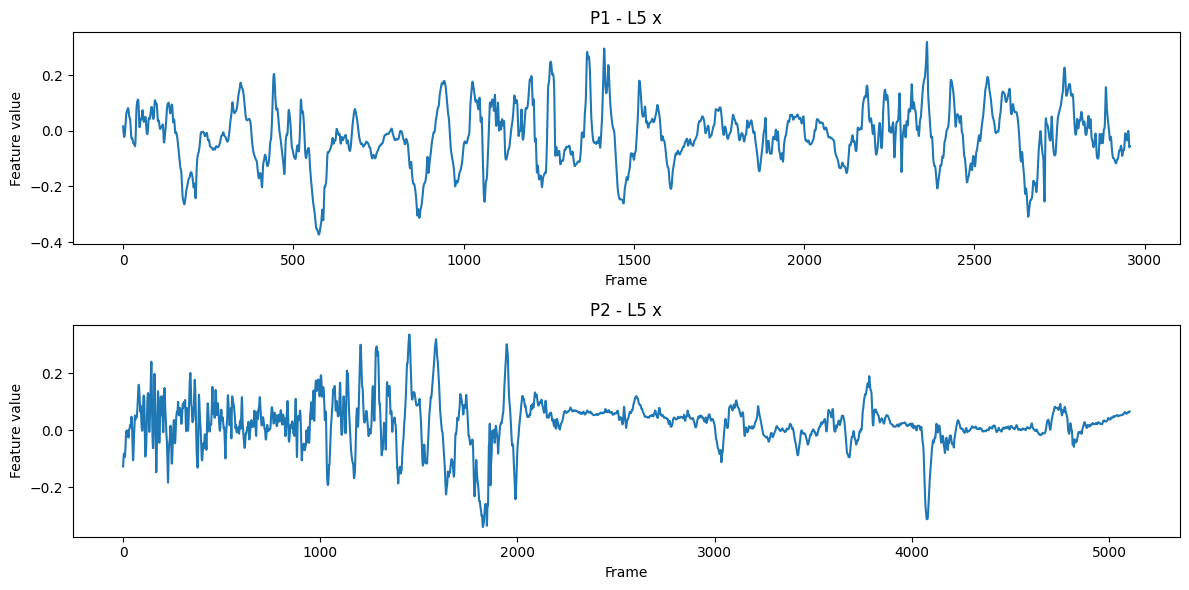

In [16]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["video_id"] == p1_df["video_id"].iloc[0]]
p2_sample = p2_df[p2_df["video_id"] == p2_df["video_id"].iloc[0]]

# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# Process Data: Split Train/Test/Val

In [17]:
print("[phase=split] splitting P1 by video_id with stratified labels")
feature_cols = get_feature_columns(p1_df)
print(f"[phase=features] feature_cols={len(feature_cols)}")
print(feature_cols)

# Build per-video labels for stratification
video_label_map = (
    p1_df.groupby("video_id")["Frame"]
    .agg(lambda s: s.mode().iloc[0])
)

p1_video_ids = video_label_map.index.values
p1_video_labels = video_label_map.values

train_vids, val_vids = train_test_split(
    p1_video_ids,
    test_size=val_split,
    random_state=seed,
    stratify=p1_video_labels,
)

train_df = p1_df[p1_df["video_id"].isin(train_vids)].copy()
val_df = p1_df[p1_df["video_id"].isin(val_vids)].copy()
test_df = p2_df.copy()

print(f"[phase=split] train_videos={len(train_vids)} val_videos={len(val_vids)}")

# Label proportions check (video-level)
from collections import Counter
print("[phase=split] label proportion (train videos)", Counter(video_label_map.loc[train_vids]))
print("[phase=split] label proportion (val videos)", Counter(video_label_map.loc[val_vids]))


[phase=split] splitting P1 by video_id with stratified labels
[phase=features] feature_cols=66
['L5 x', 'L5 y', 'L5 z', 'L3 x', 'L3 y', 'L3 z', 'T12 x', 'T12 y', 'T12 z', 'T8 x', 'T8 y', 'T8 z', 'Neck x', 'Neck y', 'Neck z', 'Head x', 'Head y', 'Head z', 'Right Shoulder x', 'Right Shoulder y', 'Right Shoulder z', 'Right Upper Arm x', 'Right Upper Arm y', 'Right Upper Arm z', 'Right Forearm x', 'Right Forearm y', 'Right Forearm z', 'Right Hand x', 'Right Hand y', 'Right Hand z', 'Left Shoulder x', 'Left Shoulder y', 'Left Shoulder z', 'Left Upper Arm x', 'Left Upper Arm y', 'Left Upper Arm z', 'Left Forearm x', 'Left Forearm y', 'Left Forearm z', 'Left Hand x', 'Left Hand y', 'Left Hand z', 'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Right Lower Leg x', 'Right Lower Leg y', 'Right Lower Leg z', 'Right Foot x', 'Right Foot y', 'Right Foot z', 'Right Toe x', 'Right Toe y', 'Right Toe z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'Left Lower Leg x', 'L

# Prepare Model Inputs: Create Windows & Normalize

In [18]:
print("[phase=preprocess] windowing + scaling")
X_train, y_train = create_windows(train_df, feature_cols, window_size, stride)
X_val, y_val = create_windows(val_df, feature_cols, window_size, stride)
X_test, y_test = create_windows(test_df, feature_cols, window_size, stride)

X_train = clean_features(X_train)
X_val = clean_features(X_val)
X_test = clean_features(X_test)

X_train, scaler = normalize_features(X_train)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

train_dataset = MotionDataset(X_train, y_train)
val_dataset = MotionDataset(X_val, y_val)
test_dataset = MotionDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

print(
    f"[phase=dataset] train_samples={len(train_dataset)} val_samples={len(val_dataset)} "
    f"test_samples(P2)={len(test_dataset)}"
)


[phase=preprocess] windowing + scaling
[phase=dataset] train_samples=6229 val_samples=2650 test_samples(P2)=8761


In [19]:
import pandas as pd

print("[phase=data] Unique labels and their counts per activity:")

# 1. Combine both datasets to get the overall count
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# 2. Group by activity_type and Label to calculate counts
overall_label_counts = combined_df.groupby(
    ['activity_type', 'Label']
).size().reset_index(name='Count')

# 3. Print the detailed breakdown
print(overall_label_counts.to_string(index=False))


[phase=data] Unique labels and their counts per activity:
activity_type                                      Label  Count
       boning                                    0- Idle  54100
       boning                                 1- Walking  13219
       boning                                2- Steeling  36590
       boning                                3- Reaching  11600
       boning                                4 - Cutting  92927
       boning                    4 - Cutting (Big Piece)   6921
       boning                   4 - Cutting (Big Pieces)  30903
       boning 4 - Cutting (offloading bone from Carcass)   6636
       boning                                 4- Cutting   9388
       boning                     4- Cutting (big piece)   5209
       boning                                5- Dropping  11634
      slicing                                   0 - Idle  10249
      slicing                                1 - Walking   1450
      slicing                               2 

In [20]:
print("[phase=data] Cleaning inconsistent labels")

# Define the mapping to standardize the labels
label_mapping = {
    '0- Idle': '0 - Idle',
    '1- Walking': '1 - Walking',
    '2- Steeling': '2 - Steeling',
    '3- Reaching': '3 - Reaching',
    '4- Cutting': '4 - Cutting',
    '5- Dropping': '5 - Dropping', # Standardizing spacing 
    '4 - Cutting (Big Piece)': '4 - Cutting (Big Pieces)',
    '4- Cutting (big piece)': '4 - Cutting (Big Pieces)'
    # Note: '8 - Dropping' and '5 - Dropping' remain distinct, 
    # but the spacing/capitalization is now unified.
}

# Apply the mapping to both P1 and P2 datasets
p1_df['Label'] = p1_df['Label'].replace(label_mapping)
p2_df['Label'] = p2_df['Label'].replace(label_mapping)

# Print out the new unique labels and their counts to verify
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)
overall_label_counts = combined_df.groupby(['activity_type', 'Label']).size().reset_index(name='Count')
print(overall_label_counts.to_string(index=False))


[phase=data] Cleaning inconsistent labels
activity_type                                      Label  Count
       boning                                   0 - Idle  54100
       boning                                1 - Walking  13219
       boning                               2 - Steeling  36590
       boning                               3 - Reaching  11600
       boning                                4 - Cutting 102315
       boning                   4 - Cutting (Big Pieces)  43033
       boning 4 - Cutting (offloading bone from Carcass)   6636
       boning                               5 - Dropping  11634
      slicing                                   0 - Idle  10249
      slicing                                1 - Walking   1450
      slicing                               2 - Steeling  12732
      slicing                               3 - Reaching  11876
      slicing                                4 - Cutting 112797
      slicing                                5 - Slicing  6099

In [21]:
import numpy as np
import pandas as pd

def add_engineered_features(df):
    """
    Computes the sheer magnitude (Euclidean norm) of velocity/acceleration 
    for key joints that dictate boning/slicing activities.
    """
    print("[phase=features] Adding engineered magnitude features...")
    df_feat = df.copy()
    
    # 1. Relevant joints for cutting/slicing (often hands/arms)
    key_joints = ['Right Hand', 'Left Hand', 'Right Forearm', 'Left Forearm', 'Right Upper Arm', 'Left Upper Arm']
    
    # 2. Add Magnitude  sqrt(x^2 + y^2 + z^2) for each key joint
    for joint in key_joints:
        x_col = f"{joint} x"
        y_col = f"{joint} y"
        z_col = f"{joint} z"
        
        # Ensure columns exist in this dataset before computing
        if all(c in df_feat.columns for c in [x_col, y_col, z_col]):
            mag_col = f"{joint} Magnitude"
            # Calculate Euclidean norm for the segment
            df_feat[mag_col] = np.sqrt(df_feat[x_col]**2 + df_feat[y_col]**2 + df_feat[z_col]**2)
            
    # 3. Add difference/relative motion between Right Hand and Left Hand (Hand coordination)
    if 'Right Hand x' in df_feat.columns and 'Left Hand x' in df_feat.columns:
        df_feat['Hands_Relative_x'] = df_feat['Right Hand x'] - df_feat['Left Hand x']
        df_feat['Hands_Relative_y'] = df_feat['Right Hand y'] - df_feat['Left Hand y']
        df_feat['Hands_Relative_z'] = df_feat['Right Hand z'] - df_feat['Left Hand z']
        
        # Magnitude of the relative difference between hands
        df_feat['Hands_Relative_Mag'] = np.sqrt(
            df_feat['Hands_Relative_x']**2 + 
            df_feat['Hands_Relative_y']**2 + 
            df_feat['Hands_Relative_z']**2
        )
        
    print(f"[phase=features] Feature count increased from {len(df.columns)} to {len(df_feat.columns)}")
    return df_feat

# Apply to your current dataframes
p1_df = add_engineered_features(p1_df)
p2_df = add_engineered_features(p2_df)

# Important: Make sure to update your `feature_cols` variable after extracting this 
# or use `get_feature_columns()` again so these new features are captured by the model!
feature_cols = get_feature_columns(p1_df) # update the selection 


[phase=features] Adding engineered magnitude features...
[phase=features] Feature count increased from 76 to 86
[phase=features] Adding engineered magnitude features...
[phase=features] Feature count increased from 76 to 86


In [22]:
import torch
import numpy as np

def augment_windows(X, y, jitter_sigma=0.02, scaling_variance=0.05, factor=1):
    """
    Applies Jittering (noise) and Scaling to the 3D windowed arrays.
    Returns the original data + the augmented data. 
    
    Args:
        X (numpy.ndarray): Shape (num_windows, window_size, num_features)
        y (numpy.ndarray): Shape (num_windows,)
        factor (int): How many augmented copies of the dataset to return.
    """
    print(f"[phase=augment] Augmenting data (Factor: {factor}x)")
    aug_X, aug_y = [X], [y]
    
    for _ in range(factor):
        # 1. Jittering: Add simple Gaussian noise to simulate sensor noise
        noise = np.random.normal(loc=0, scale=jitter_sigma, size=X.shape)
        X_jittered = X + noise
        
        # 2. Scaling: Randomly scale the amplitude slightly higher/lower 
        # (simulates people moving slightly faster or slower overall in that window)
        # We generate a single scale factor per window/sequence
        scale_factors = np.random.normal(loc=1.0, scale=scaling_variance, size=(X.shape[0], 1, 1))
        X_scaled = X_jittered * scale_factors
        
        aug_X.append(X_scaled)
        aug_y.append(y)
        
    return np.concatenate(aug_X, axis=0), np.concatenate(aug_y, axis=0)

# -----------------
# Usage in your pipeline: 
# Only augment X_train! Never augment X_val or X_test.
# Apply this immediately AFTER normalize_features() and BEFORE creating MotionDataset
# -----------------

print(f"[phase=dataset] Original X_train shape: {X_train.shape}")

# This will essentially DOUBLE your training data size (original + 1 augmented copy)
X_train_aug, y_train_aug = augment_windows(X_train, y_train, jitter_sigma=0.02, factor=1)

print(f"[phase=dataset] Augmented X_train shape: {X_train_aug.shape}")

# Then use the augmented shapes to build your dataloader
# train_dataset = MotionDataset(X_train_aug, y_train_aug)


[phase=dataset] Original X_train shape: (6229, 60, 66)
[phase=augment] Augmenting data (Factor: 1x)
[phase=dataset] Augmented X_train shape: (12458, 60, 66)


In [23]:
import torch
import torch.nn as nn
from tqdm import tqdm # Optional: for progress bars during epochs

print("[phase=model] Defining BiLSTM Architecture")

# 1. Define the BiLSTM Model Class
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(ActivityBiLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected layers mapping to the number of unique labels
        # Bidirectional means the hidden state is 2 * hidden_size
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        # Final output layer
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, sequence_length/window_size, input_size/features)
        
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # We only need the output from the last time step in the window for classification
        # out shape: (batch_size, seq_len, hidden_size * 2)
        out = out[:, -1, :] 
        
        # Pass through fully connected network
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out


# 2. Instantiate Model, Loss, and Optimizer
print("[phase=train] Initializing model and hyperparams...")

input_features = X_train_aug.shape[2] # Number of columns after feature engineering
num_classes = len(encoder.classes_)   # Matches the unique labels from LabelEncoder

model = ActivityBiLSTM(
    input_size=input_features, 
    hidden_size=128, 
    num_layers=2, 
    num_classes=num_classes,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print(f"Model Summary:\n{model}")
print(f"Input Features: {input_features} | Output Classes: {num_classes}")


[phase=model] Defining BiLSTM Architecture
[phase=train] Initializing model and hyperparams...
Model Summary:
ActivityBiLSTM(
  (lstm): LSTM(66, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Input Features: 66 | Output Classes: 2
